# 06. Regressão Linear — Parte 1
## Beta CAPM: se o mercado cair 10%, quanto cai ITUB3?

---

## Cenário

Você é analista de risco de mercado. O gestor sênior te chama antes do comitê de alocação:

> *"O fundo tem uma posição relevante em ITUB3. Se o mercado cair 10% amanhã, quanto essa ação deve cair? Ela amplifica o mercado ou atenua?"*

Essa pergunta tem uma resposta quantitativa. O **Beta do CAPM**, estimado por regressão linear simples, é a ferramenta para encontrá-la.

---

## Estrutura do notebook

| Seção | Conteúdo | Entregável |
|---|---|---|
| [1. Dados](#sec-dados) | yfinance → retornos mensais ITUB3 e Ibovespa | — |
| [2. EDA](#sec-eda) | Scatter e correlação | — |
| [3. Hipótese](#sec-hipotese) | CAPM, SML e hipótese β > 1 | **⭐ Entregável** |
| [4. Modelo](#sec-modelo) | Regressão com sklearn, Beta, Alfa, R² | **⭐ Entregável** |
| [5. Resíduos](#sec-residuos) | Diagnóstico gráfico | **⭐ Entregável** |
| [6. Conclusão](#sec-conclusao) | Mensagem para o gestor + limitações | — |

<a id="sec-dados"></a>

---

## 1. Dados

In [137]:
# ── Manipulação de dados ──────────────────────────────────────────────────────
import warnings
import numpy as np          # álgebra vetorial: cálculos numéricos sobre arrays
import pandas as pd         # DataFrames: estrutura principal para séries temporais

# ── Coleta de dados de mercado ────────────────────────────────────────────────
import yfinance as yf       # acessa a API pública do Yahoo Finance sem autenticação

# ── Visualização ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt  # engine de gráficos
import seaborn as sns            # camada de alto nível sobre matplotlib

# ── Estatística ───────────────────────────────────────────────────────────────
from scipy import stats          # correlação de Pearson e testes estatísticos

# ── Modelo de regressão ───────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression  # OLS: minimiza soma dos quadrados dos resíduos
from sklearn.metrics import r2_score               # R²: proporção da variância explicada pelo modelo

# ── Diagnóstico de resíduos ───────────────────────────────────────────────────
from statsmodels.nonparametric.smoothers_lowess import lowess  # curva suave local para detectar padrões

warnings.filterwarnings('ignore')
np.random.seed(42)  # garante reprodutibilidade em qualquer operação com aleatoriedade

# Estilo visual padrão para todos os gráficos do notebook
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.facecolor': 'white',
})

In [138]:
# 10 anos cobrem múltiplos ciclos — bull market (período de alta sustentada), crise COVID e ciclo de juros
# Um Beta estimado em apenas um regime (só alta ou só baixa) seria pouco confiável
START, END = '2015-01-01', '2024-12-31'

# auto_adjust=True: preços já ajustados por dividendos e desdobramentos
# Sem esse ajuste, splits de ações criam quedas artificiais que distorceriam o Beta
raw_itub = yf.download('ITUB3.SA', start=START, end=END, auto_adjust=True, progress=False)
raw_ibov = yf.download('^BVSP',    start=START, end=END, auto_adjust=True, progress=False)

# .squeeze() converte DataFrame de uma coluna em Series simples
preco_itub = raw_itub['Close'].squeeze().rename('ITUB3')
preco_ibov = raw_ibov['Close'].squeeze().rename('IBOV')

# resample('ME').last(): pega o preço do último pregão de cada mês
# Isso evita trabalhar com 119×22 = ~2600 observações diárias e reduz ruído de curto prazo
#
# Retorno logarítmico: r_t = ln(P_t / P_{t-1})
# Preferido em finanças porque: (1) é aditivo no tempo, (2) mais simétrico,
# (3) ln(P_t/P_{t-1}) ≈ (P_t - P_{t-1})/P_{t-1} para variações pequenas
df = pd.DataFrame({
    'r_itub': np.log(preco_itub.resample('ME').last() / preco_itub.resample('ME').last().shift(1)),
    'r_ibov': np.log(preco_ibov.resample('ME').last() / preco_ibov.resample('ME').last().shift(1)),
}).dropna()  # dropna() remove o primeiro mês (NaN por não ter mês anterior para calcular retorno)

print(f'Período: {df.index.min().strftime("%b/%Y")} a {df.index.max().strftime("%b/%Y")} | {len(df)} observações mensais')
print()
# Multiplica por 100 para exibir em % — os dados internos ficam em decimal (0.01 = 1%)
(df * 100).describe().round(2)

Período: Feb/2015 a Dec/2024 | 119 observações mensais



,r_itub,r_ibov
count,119.00,119.00
mean,0.90,0.79
std,7.82,6.61
min,-25.86,-35.53
25%,-3.74,-3.10
50%,0.87,0.70
75%,6.82,5.53
max,16.44,15.67


**Leituras dos dados:**

- **Volatilidade:** O desvio padrão de ITUB3 é maior que o do Ibovespa — primeiro indício de que a ação amplifica movimentos do mercado.
- **Mínimo:** O pior mês de ambas as séries coincide com março/2020 (crash COVID). Quando o mercado inteiro cai junto, não há diversificação possível — isso é **risco sistemático** (risco que afeta todos os ativos ao mesmo tempo; definido formalmente na seção 3) em ação.
- **10 anos de dados** cobrem bull market — período de alta sustentada — (2016–2019), crash e recuperação COVID (2020), ciclo de alta de juros (2021–2023).

<a id="sec-eda"></a>

---

## 2. Análise Exploratória

Antes de qualquer modelo: **ver os dados**. A pergunta central é se a relação entre ITUB3 e o Ibovespa parece linear — verificação visual necessária antes de assumir qualquer estrutura de modelo.

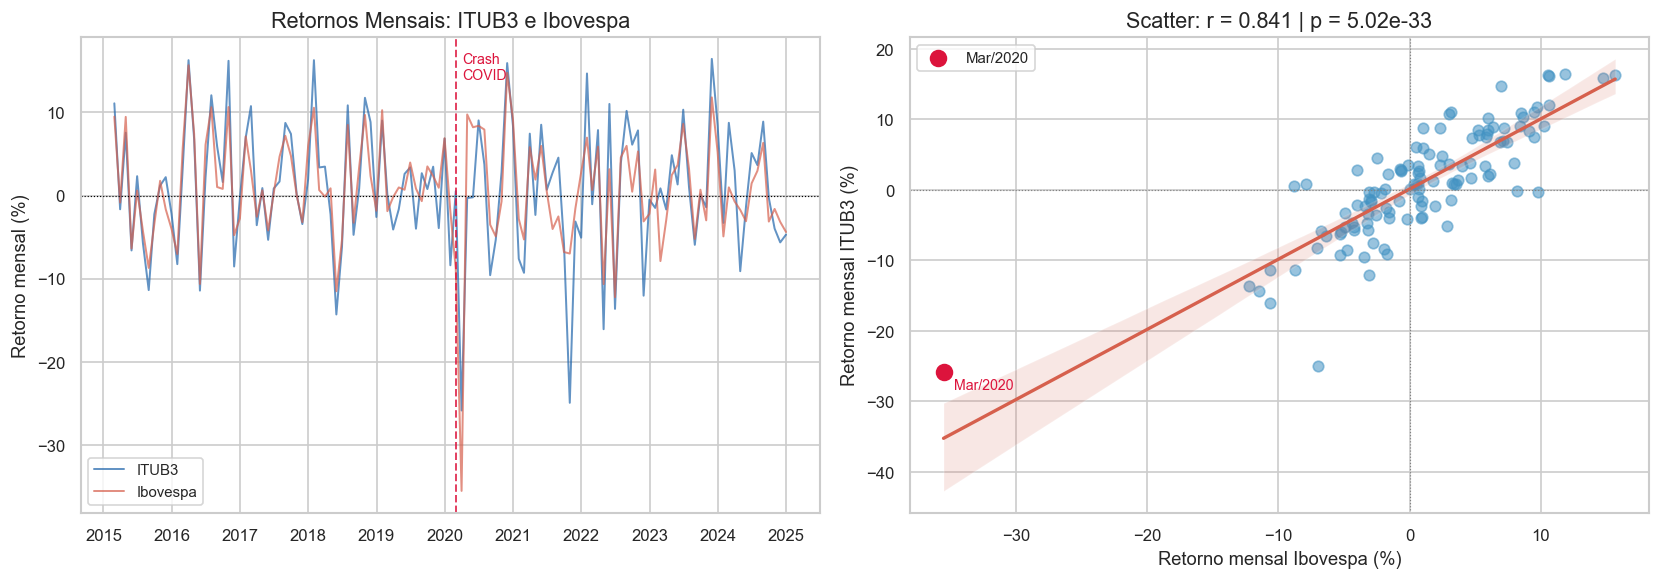

Correlação de Pearson: r = 0.8412 | p-valor = 5.0160e-33


In [139]:
# Correlação de Pearson: mede força e direção da relação linear entre −1 e +1
# p-valor testa H0: "a correlação é zero" — se p < 0.05, rejeitamos e concluímos que há relação
r_pearson, p_valor = stats.pearsonr(df['r_ibov'], df['r_itub'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Painel esquerdo: séries temporais sobrepostas ─────────────────────────────
# Objetivo: ver visualmente se as séries se movem juntas (co-movimento)
ax = axes[0]
ax.plot(df.index, df['r_itub'] * 100, alpha=0.7, linewidth=1.2, label='ITUB3', color='#2166ac')
ax.plot(df.index, df['r_ibov'] * 100, alpha=0.7, linewidth=1.2, label='Ibovespa', color='#d6604d')
ax.axhline(0, color='black', linewidth=0.7, linestyle=':')
# Marca o crash COVID: o pior mês simultâneo de ambas as séries
ax.axvline(pd.Timestamp('2020-03-01'), color='crimson', linestyle='--', linewidth=1.2, alpha=0.8)
ax.text(pd.Timestamp('2020-04-01'), 14, 'Crash\nCOVID', fontsize=8.5, color='crimson')
ax.set_ylabel('Retorno mensal (%)')
ax.set_title('Retornos Mensais: ITUB3 e Ibovespa')
ax.legend(fontsize=9)

# ── Painel direito: scatter com reta ajustada e IC 95% ───────────────────────
# Objetivo: verificar se a relação parece linear (premissa da regressão)
# ci=95: banda de confiança de 95% ao redor da reta — quanto mais estreita, mais precisa a estimativa
ax = axes[1]
sns.regplot(
    data=df * 100, x='r_ibov', y='r_itub',
    scatter_kws={'alpha': 0.55, 's': 40, 'color': '#4393c3'},
    line_kws={'color': '#d6604d', 'linewidth': 2},
    ci=95, ax=ax
)

# Destaca o crash de mar/2020: ponto mais extremo e de maior influência sobre o Beta
crash = df.loc['2020-03']
ax.scatter(crash['r_ibov'] * 100, crash['r_itub'] * 100,
           color='crimson', s=90, zorder=5, label='Mar/2020')
ax.annotate('Mar/2020', (crash['r_ibov'] * 100, crash['r_itub'] * 100),
            xytext=(6, -10), textcoords='offset points', fontsize=8.5, color='crimson')
ax.axhline(0, color='gray', linewidth=0.7, linestyle=':')
ax.axvline(0, color='gray', linewidth=0.7, linestyle=':')
ax.set_xlabel('Retorno mensal Ibovespa (%)')
ax.set_ylabel('Retorno mensal ITUB3 (%)')
ax.set_title(f'Scatter: r = {r_pearson:.3f} | p = {p_valor:.2e}')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()
print(f'Correlação de Pearson: r = {r_pearson:.4f} | p-valor = {p_valor:.4e}')

**O que o scatter nos conta antes de qualquer modelo:**

1. **Correlação forte e significante** — o p-valor indica que a probabilidade de observar essa correlação por acaso é essencialmente zero. Há um fator comum movendo os dois ativos.

2. **Relação visualmente linear** — a nuvem de pontos se organiza em torno de uma reta sem curvatura evidente, o que justifica prosseguir com regressão linear.

3. **Mar/2020 (crash COVID)** — ponto extremo, distante da nuvem central. Observações muito afastadas da maioria podem exercer influência desproporcional sobre qualquer reta ajustada aos dados — isso será investigado no diagnóstico do modelo.

<a id="sec-hipotese"></a>

---

## 3. Hipótese ⭐

### 3.1 Justificativa teórica

Em um mercado financeiro, nenhum ativo se move de forma completamente isolada. Há um fator comum que afeta todos ao mesmo tempo — crises, expansões, choques de política monetária. Esse é o **risco sistemático**: o risco que a diversificação não consegue eliminar.

O **CAPM** (Capital Asset Pricing Model, Sharpe 1964) formaliza essa ideia: o retorno de qualquer ativo se decompõe em dois componentes:

$$\underbrace{\beta \cdot r_{\text{mercado}}}_{\text{sistemático — explicado pelo mercado}} \;+\; \underbrace{\varepsilon}_{\text{idiossincrático — específico do ativo}}$$

O Ibovespa é o proxy natural para o "mercado" no Brasil — composto pelas ações mais líquidas da B3, captura o comportamento médio do mercado doméstico. Para bancos, a ligação é especialmente forte. O canal de transmissão é direto:

```
Ibovespa cai → apetite por risco ↓ → venda de ativos de risco (bancos incluídos)
             → expectativa de recessão ↑ → inadimplência esperada ↑
               → valuation do banco ↓ (provisão maior, margem financeira menor)
```

Bancos são **pró-cíclicos por natureza**: seus lucros crescem na expansão (crédito aquecido, spreads maiores) e contraem na recessão (inadimplência, queda de volume). A forte correlação observada na EDA não é coincidência — é estrutural.

---

### 3.2 Formalização: a Linha de Mercado do Título

Com o contexto teórico estabelecido e a relação linear confirmada visualmente na EDA, podemos formalizar o modelo. A **Linha de Mercado do Título (SML — Security Market Line)** expressa o retorno de um ativo em função do seu risco sistemático:

$$r_{\text{ITUB3},\,t} = \alpha + \beta \cdot r_{\text{IBOV},\,t} + \varepsilon_t$$

> Esta é a versão *empírica* da SML — usa retornos realizados no lugar de retornos esperados e omite a taxa livre de risco (Selic) por simplicidade. Para os fins deste estudo, a simplificação é adequada.

| Parâmetro | Nome | O que mede |
|---|---|---|
| $\beta$ | Beta do CAPM | Quanto ITUB3 se move para cada 1% do Ibovespa |
| $\alpha$ | Alfa de Jensen | Retorno médio além do explicado pelo mercado |
| $\varepsilon_t$ | Retorno anormal | O que o modelo não consegue explicar — eventos específicos do banco |

---

### 3.3 Hipótese

Se bancos são pró-cíclicos, o Beta de ITUB3 deve ser **maior que 1** — a ação amplifica os movimentos do mercado.

| β | Comportamento esperado |
|---|---|
| β > 1 | Ibovespa cai 10% → ITUB3 cai *mais* que 10% |
| β = 1 | Ibovespa cai 10% → ITUB3 cai exatamente 10% |
| β < 1 | Ibovespa cai 10% → ITUB3 cai *menos* que 10% |

A evidência histórica apoia β > 1: no crash COVID (mar/2020) o Ibovespa caiu −29% e ITUB3 caiu além disso; na recuperação seguinte, ITUB3 subiu acima do índice.

O **R²** complementa o Beta com uma pergunta diferente: *qual fração do risco total de ITUB3 é de origem sistemática?*

$$R^2 = \frac{\text{Risco Sistemático}}{\text{Risco Total}}$$

Para um banco pró-cíclico, esperamos R² elevado — a maior parte do risco não é diversificável. O que sobrar (1 − R²) é risco específico do Itaú: gestão, inadimplência da carteira, regulação.

> A seção seguinte estima o Beta empiricamente. A hipótese é β > 1 — os dados terão a palavra final.

<a id="sec-modelo"></a>

---

## 4. Modelo — Regressão com sklearn ⭐

A hipótese está formulada: esperamos β > 1, com ITUB3 amplificando os movimentos do Ibovespa. Agora precisamos *estimar* α e β a partir dos dados históricos.

O método é o **OLS (Ordinary Least Squares — Mínimos Quadrados Ordinários)**. De todas as retas que poderiam passar pela nuvem de pontos do scatter, o OLS escolhe a que minimiza a soma dos quadrados das distâncias verticais entre cada ponto observado e a reta:

$$\min_{\alpha,\,\beta} \sum_{t=1}^{n} \left(r_{\text{ITUB3},t} - \alpha - \beta \cdot r_{\text{IBOV},t}\right)^2$$

Elevar ao quadrado penaliza erros grandes de forma desproporcional — um erro de 10% pesa 100× mais que um de 1% — e garante uma única solução, pois a função de custo quadrática é estritamente convexa. É o que `LinearRegression()` do sklearn executa internamente.

**O que interpretar nos resultados:**

| Saída | O que mede | O que observar |
|---|---|---|
| **β** | Sensibilidade ao mercado | > 1: amplifica / = 1: replica / < 1: atenua |
| **α** | Retorno além do que o Beta justifica | ≈ 0 esperado em mercados eficientes (HEM)* |
| **R²** | Fração do risco explicada pelo mercado | Quanto mais alto, mais sistemático o risco |
| **RMSE** | Erro médio mensal do modelo | Incerteza ao redor de cada previsão |

*HEM — Hipótese de Eficiência de Mercado: em mercados competitivos, preços refletem toda informação disponível e retornos anormais persistentes são eliminados pela arbitragem.

In [140]:
# sklearn exige que X seja uma matriz 2D (linhas = observações, colunas = features)
# reshape(-1, 1): converte o array 1D [n] para matriz [n, 1] — 119 meses, 1 variável
X = df['r_ibov'].values.reshape(-1, 1)  # variável explicativa: retorno do Ibovespa
y = df['r_itub'].values                 # variável dependente: retorno de ITUB3

# LinearRegression() usa OLS internamente:
# encontra α e β que minimizam Σ(y_i - α - β·x_i)² — a soma dos quadrados dos erros
modelo = LinearRegression()
modelo.fit(X, y)              # ajusta o modelo aos dados históricos
y_pred = modelo.predict(X)   # y_pred[i] = α + β × r_ibov[i]  para cada mês i
residuos = y - y_pred         # resíduo = o que o modelo não conseguiu explicar

# Extrai os parâmetros estimados pelo OLS
alfa = modelo.intercept_  # Alfa de Jensen: retorno médio não explicado pelo mercado
beta = modelo.coef_[0]    # coef_ é sempre um array mesmo com 1 feature — [0] extrai o escalar Beta

# Métricas de qualidade do ajuste
r2   = r2_score(y, y_pred)              # R² = SSR/SST: proporção da variância explicada
rmse = np.sqrt(np.mean(residuos ** 2))  # raiz do erro quadrático médio — na unidade original (decimal)

print('=== Modelo estimado ===')
print(f'  r_ITUB3 = {alfa*100:.4f}% + {beta:.4f} × r_IBOV')
print()
print(f'  Alfa de Jensen  α = {alfa*100:.4f}% ao mês  ({((1+alfa)**12-1)*100:+.2f}% a.a.)')
print(f'  Beta CAPM       β = {beta:.4f}')
print()
print(f'  R²   = {r2:.4f}  ({r2*100:.1f}% da volatilidade de ITUB3 é sistemática)')
print(f'  RMSE = {rmse*100:.2f} p.p.  (erro médio mensal do modelo)')

=== Modelo estimado ===
  r_ITUB3 = 0.1157% + 0.9956 × r_IBOV

  Alfa de Jensen  α = 0.1157% ao mês  (+1.40% a.a.)
  Beta CAPM       β = 0.9956

  R²   = 0.7076  (70.8% da volatilidade de ITUB3 é sistemática)
  RMSE = 4.21 p.p.  (erro médio mensal do modelo)


**Resultado vs. hipótese:** β = 0,9956 — praticamente igual a 1. Para fins práticos, ITUB3 *replicou* o mercado ao longo do período, não amplificou. A hipótese de β > 1 não se confirmou.

Isso não invalida o raciocínio teórico. O período 2015–2024 mistura regimes muito distintos — bull market, COVID, ciclo de alta de juros — e um Beta *médio* de 10 anos pode mascarar períodos em que ITUB3 claramente amplificou e outros em que atenuou. O Beta Rolling (Parte 2) vai revelar essa instabilidade.

**R² = 0,71** é elevado para uma ação individual — a maioria das ações brasileiras fica entre 0,30 e 0,60 contra o Ibovespa. Confirma que o risco de ITUB3 é predominantemente sistemático, consistente com a tese de que bancos são pró-cíclicos. O que sobra (29%) é risco específico do Itaú: gestão, inadimplência da carteira, regulação.

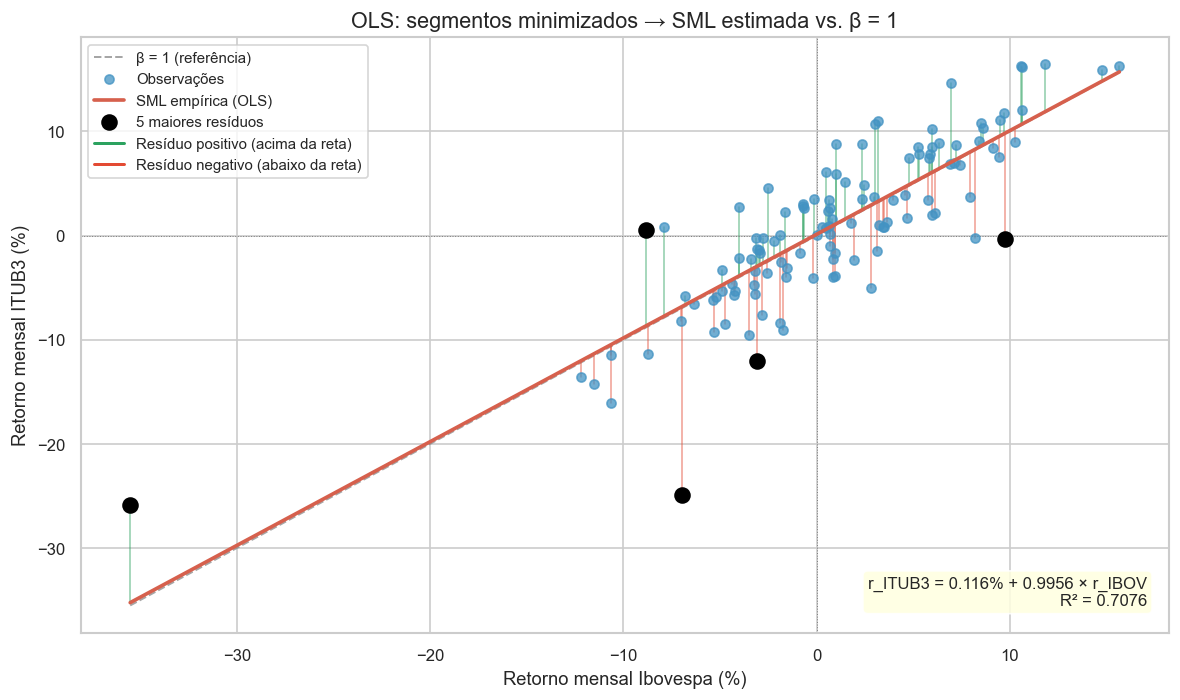

In [141]:
fig, ax = plt.subplots(figsize=(10, 6))

x_linha = np.linspace(X.min(), X.max(), 200)

# Diagonal de 45°: representa β = 1 — ITUB3 replicando o mercado perfeitamente
# A posição da reta OLS em relação a esta diagonal revela se β > 1 ou β < 1
ax.plot(x_linha * 100, x_linha * 100,
        color='gray', linewidth=1.2, linestyle='--', alpha=0.7, label='β = 1 (referência)', zorder=1)

# Segmentos verticais: cada linha conecta o ponto observado ao seu valor predito na reta
# É exatamente isso que o OLS minimiza — a soma dos quadrados dessas distâncias
# X.flatten(): X foi reshape para 2D ([n,1]) para o sklearn; flatten() volta para 1D ([n]) para iterar
for xi, yi, ypi, ei in zip(X.flatten(), y, y_pred, residuos):
    cor = '#2ca25f' if ei >= 0 else '#e34a33'  # verde = acima da reta, vermelho = abaixo
    ax.plot([xi * 100, xi * 100], [ypi * 100, yi * 100],
            color=cor, linewidth=0.9, alpha=0.55, zorder=2)

# Pontos observados
ax.scatter(X * 100, y * 100, s=30, color='#4393c3', alpha=0.75, zorder=3, label='Observações')

# Reta OLS ajustada: SML empírica — resultado final da minimização
ax.plot(x_linha * 100, (alfa + beta * x_linha) * 100,
        color='#d6604d', linewidth=2.2, zorder=4, label='SML empírica (OLS)')

# Destaca os 5 maiores resíduos — os pontos que mais "puxam" a reta
# argsort ordena os índices em ordem crescente de |resíduo|; [-5:] pega os 5 últimos (maiores)
idx_top = np.argsort(np.abs(residuos))[-5:]
ax.scatter(X.flatten()[idx_top] * 100, y[idx_top] * 100,
           s=80, color='black', zorder=5, label='5 maiores resíduos')

# ax.plot([], []) cria uma entrada de legenda sem desenhar nada no gráfico (proxy legend)
# Necessário porque os segmentos foram adicionados via loop e não têm label individual
ax.plot([], [], color='#2ca25f', linewidth=1.8, label='Resíduo positivo (acima da reta)')
ax.plot([], [], color='#e34a33', linewidth=1.8, label='Resíduo negativo (abaixo da reta)')

ax.axhline(0, color='gray', linewidth=0.6, linestyle=':')
ax.axvline(0, color='gray', linewidth=0.6, linestyle=':')
ax.set_xlabel('Retorno mensal Ibovespa (%)')
ax.set_ylabel('Retorno mensal ITUB3 (%)')
ax.set_title('OLS: segmentos minimizados → SML estimada vs. β = 1')
ax.legend(fontsize=9, loc='upper left')

# Equação estimada e R² para referência rápida durante a apresentação
equacao = f'r_ITUB3 = {alfa*100:.3f}% + {beta:.4f} × r_IBOV\nR² = {r2:.4f}'
ax.text(0.98, 0.04, equacao, transform=ax.transAxes, fontsize=10,
        va='bottom', ha='right', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.85))

plt.tight_layout()
plt.show()

**O que o gráfico mostra:**

- **SML estimada (linha vermelha) quase coincide com a diagonal β = 1 (cinza)** — confirma visualmente β ≈ 1: na média do período, ITUB3 replicou o mercado em vez de amplificá-lo.
- **Segmentos maiores nos extremos** — os maiores erros concentram-se em meses de retornos intensos (alta ou baixa), não distribuídos uniformemente ao longo da reta. Esse padrão é heteroscedasticidade e será auditado na seção 5.
- **5 maiores resíduos (pontos pretos) não são aleatórios** — correspondem a eventos específicos (COVID, ciclo de juros) que moveram ITUB3 de forma descolada do Ibovespa. São exatamente os pontos que mais influenciam o β estimado.

In [142]:
# === Cenário: Ibovespa −10% ===
# Aplica o modelo estimado à pergunta que abriu o notebook

queda_ibov = -0.10  # queda hipotética de 10% no Ibovespa

# Previsão pontual do modelo: α + β × queda
retorno_previsto = alfa + beta * queda_ibov

# O RMSE mede o erro médio do modelo — uma diferença menor que o RMSE
# não é estatisticamente distinguível de β = 1 (o modelo não consegue separar os dois)
diferenca = abs(retorno_previsto) - abs(queda_ibov)  # positivo: amplifica; negativo: atenua
if abs(diferenca) < rmse:
    classificacao_str = (f'essencialmente igual ao mercado '
                         f'(diferença de {abs(diferenca)*100:.2f} p.p. < RMSE de {rmse*100:.2f} p.p.)')
elif diferenca > 0:
    classificacao_str = 'amplifica a queda do mercado'
else:
    classificacao_str = 'atenua a queda do mercado'

print('=== Cenário: Ibovespa −10% ===')
print()
print(f'  Previsão pontual : ITUB3 deve cair {abs(retorno_previsto)*100:.1f}%')
print(f'  Incerteza (RMSE) : ±{rmse*100:.1f} p.p.  →  intervalo [{(retorno_previsto - rmse)*100:.1f}%, {(retorno_previsto + rmse)*100:.1f}%]')
print()
print(f'  Classificação: ITUB3 {classificacao_str}')
print()
print(f'  Interpretação: β = {beta:.4f} ≈ 1; a diferença de {abs(diferenca)*100:.2f} p.p. entre')
print(f'  a queda prevista e os 10% exatos é menor que o erro médio do modelo ({rmse*100:.2f} p.p.).')
print(f'  Não há evidência suficiente para afirmar que ITUB3 amplifica ou atenua nesse cenário.')

=== Cenário: Ibovespa −10% ===

  Previsão pontual : ITUB3 deve cair 9.8%
  Incerteza (RMSE) : ±4.2 p.p.  →  intervalo [-14.1%, -5.6%]

  Classificação: ITUB3 essencialmente igual ao mercado (diferença de 0.16 p.p. < RMSE de 4.21 p.p.)

  Interpretação: β = 0.9956 ≈ 1; a diferença de 0.16 p.p. entre
  a queda prevista e os 10% exatos é menor que o erro médio do modelo (4.21 p.p.).
  Não há evidência suficiente para afirmar que ITUB3 amplifica ou atenua nesse cenário.


<a id="sec-residuos"></a>

---

## 5. Análise dos Resíduos ⭐

O modelo está estimado e a hipótese avaliada. Antes de levar os resultados ao gestor, uma pergunta crítica: **o modelo é confiável?**

A ferramenta de auditoria são os resíduos — os erros do modelo. Em finanças, esses erros têm nome: **retornos anormais** (*abnormal returns*). São os movimentos de ITUB3 que o Ibovespa não conseguiu explicar — eventos específicos do banco.

Em um modelo bem especificado, os resíduos são ruído puro: aleatórios, sem padrão, distribuídos em torno de zero. Qualquer estrutura que encontrarmos é sinal de que o modelo deixou algo para trás.

| Padrão | O que indica | Consequência |
|---|---|---|
| LOWESS horizontal | Linearidade adequada | OLS é BLUE (melhor estimador linear não-viesado) |
| Dispersão crescente | Heteroscedasticidade | Intervalos de confiança (ICs) inválidos |
| Caudas pesadas | Não-normalidade dos erros | OLS subestima probabilidade de eventos extremos |
| Clusters sistemáticos | Variável omitida | Coeficientes potencialmente viesados |

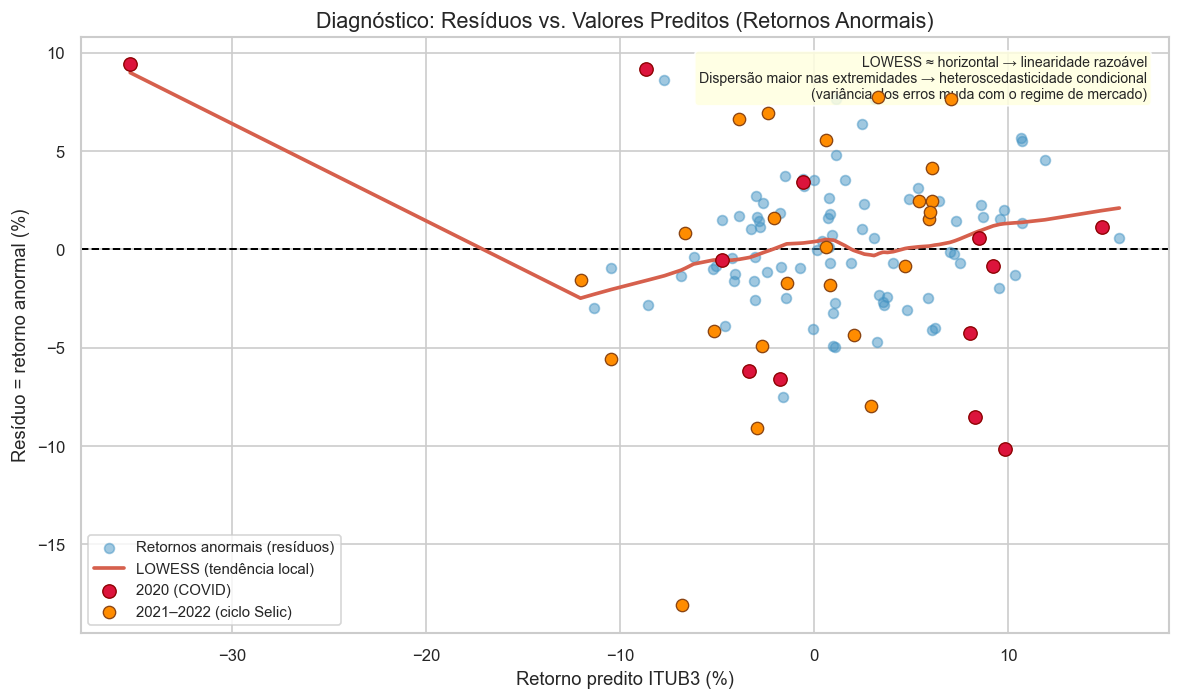

In [143]:
# LOWESS (Locally Weighted Scatterplot Smoothing): ajusta uma curva suave localmente
# sem assumir forma funcional — ideal para detectar padrões sistemáticos nos resíduos
# frac=0.4: cada ponto usa os 40% de vizinhos mais próximos para calcular a média local
# return_sorted=True: retorna os pontos ordenados por y_pred para que a linha seja contínua
smooth = lowess(residuos, y_pred, frac=0.4, return_sorted=True)

fig, ax = plt.subplots(figsize=(10, 6))

# Cada ponto é um mês: eixo X = o que o modelo previu, eixo Y = o erro que o modelo cometeu
# Em um modelo bem especificado, os resíduos ficam aleatoriamente em torno de zero,
# sem nenhum padrão discernível — o erro seria "ruído branco"
ax.scatter(y_pred * 100, residuos * 100,
           alpha=0.5, s=35, color='#4393c3', zorder=3, label='Retornos anormais (resíduos)')

# Linha de referência: resíduos perfeitamente aleatórios ficam em torno desta linha
ax.axhline(0, color='black', linewidth=1.2, linestyle='--')

# Curva LOWESS: se não for aproximadamente horizontal → há padrão sistemático → má especificação
ax.plot(smooth[:, 0] * 100, smooth[:, 1] * 100,
        color='#d6604d', linewidth=2.2, label='LOWESS (tendência local)', zorder=4)

# Pontos de 2020: crash COVID gerou retornos anormais extremos
# Esses meses concentram os maiores erros absolutos do modelo
mask_covid = df.index.year == 2020
ax.scatter(y_pred[mask_covid] * 100, residuos[mask_covid] * 100,
           color='crimson', s=65, zorder=5, edgecolors='darkred', linewidth=0.8,
           label='2020 (COVID)')

# Pontos de 2021-2022: alta da Selic beneficiou bancos de forma diferente do restante do Ibovespa
# Isso pode gerar resíduos sistematicamente positivos (modelo subestima ITUB3) no período
mask_selic = df.index.year.isin([2021, 2022])
ax.scatter(y_pred[mask_selic] * 100, residuos[mask_selic] * 100,
           color='darkorange', s=55, zorder=5, edgecolors='saddlebrown', linewidth=0.8,
           label='2021–2022 (ciclo Selic)')

ax.set_xlabel('Retorno predito ITUB3 (%)')
ax.set_ylabel('Resíduo = retorno anormal (%)')
ax.set_title('Diagnóstico: Resíduos vs. Valores Preditos (Retornos Anormais)')
ax.legend(fontsize=9)

ax.text(0.98, 0.97,
        'LOWESS ≈ horizontal → linearidade razoável\n'
        'Dispersão maior nas extremidades → heteroscedasticidade condicional\n'
        '(variância dos erros muda com o regime de mercado)',
        transform=ax.transAxes, fontsize=8.5, va='top', ha='right',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.85))

plt.tight_layout()
plt.show()

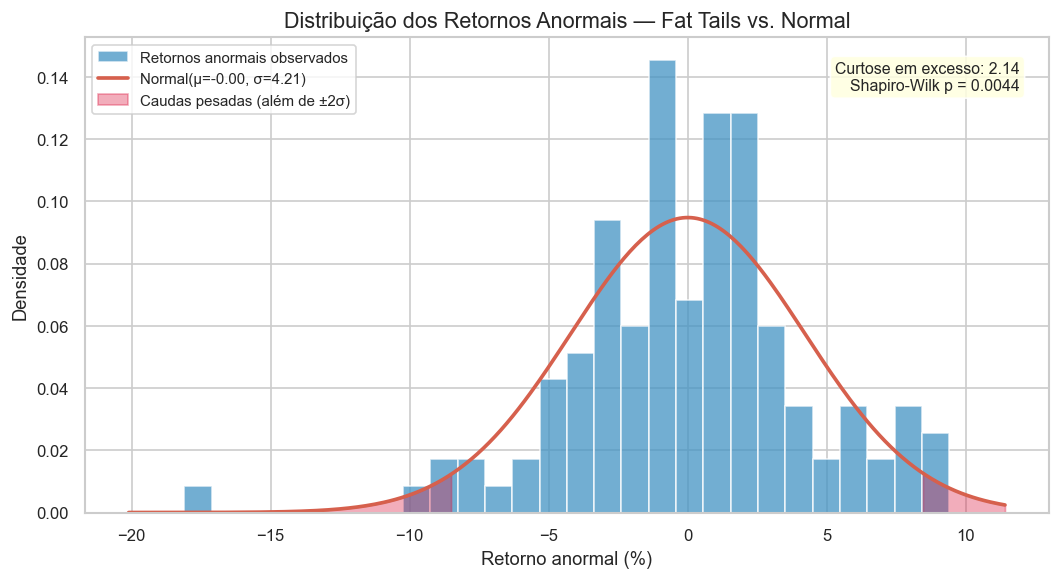

In [144]:
mu_e, sigma_e = (residuos * 100).mean(), (residuos * 100).std()
x_norm = np.linspace((residuos * 100).min() - 2, (residuos * 100).max() + 2, 300)

fig, ax = plt.subplots(figsize=(9, 5))

# density=True: normaliza o histograma para que a área total = 1 (densidade de probabilidade)
# Sem isso, o eixo Y seria contagem de observações e a curva PDF não teria a mesma escala
ax.hist(residuos * 100, bins=28, color='#4393c3', edgecolor='white', alpha=0.75,
        density=True, label='Retornos anormais observados')

# stats.norm.pdf(): função densidade de probabilidade da normal — devolve a altura da curva em cada x
# Usamos a normal com mesma média e desvio dos resíduos como referência teórica do OLS
ax.plot(x_norm, stats.norm.pdf(x_norm, mu_e, sigma_e),
        color='#d6604d', linewidth=2.2, label=f'Normal(μ={mu_e:.2f}, σ={sigma_e:.2f})')

# Sombreia as caudas além de ±2σ para evidenciar os eventos extremos
limiar = 2 * sigma_e
x_cauda_esq = x_norm[x_norm < mu_e - limiar]
x_cauda_dir = x_norm[x_norm > mu_e + limiar]
ax.fill_between(x_cauda_esq, stats.norm.pdf(x_cauda_esq, mu_e, sigma_e),
                color='crimson', alpha=0.35, label='Caudas pesadas (além de ±2σ)')
ax.fill_between(x_cauda_dir, stats.norm.pdf(x_cauda_dir, mu_e, sigma_e),
                color='crimson', alpha=0.35)

# stats.kurtosis(): retorna curtose em *excesso* — normal = 0 (não 3)
# Valores positivos indicam caudas mais pesadas que a normal (leptocúrtica)
kurt = stats.kurtosis(residuos)

# stats.shapiro(): teste Shapiro-Wilk de normalidade
# H0: "os dados vêm de uma distribuição normal"
# p < 0.05 → rejeitamos H0 → evidência de não-normalidade
stat_sw, p_sw = stats.shapiro(residuos)

ax.text(0.97, 0.95,
        f'Curtose em excesso: {kurt:.2f}\nShapiro-Wilk p = {p_sw:.4f}',
        transform=ax.transAxes, fontsize=9.5, va='top', ha='right',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.85))

ax.set_xlabel('Retorno anormal (%)')
ax.set_ylabel('Densidade')
ax.set_title('Distribuição dos Retornos Anormais — Fat Tails vs. Normal')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

Os dois gráficos, lidos em sequência, contam uma história coerente.

**A linearidade está razoavelmente satisfeita.** A curva LOWESS é aproximadamente horizontal — sem curvatura relevante. O modelo linear é uma boa aproximação para a relação entre ITUB3 e Ibovespa.

**Mas a variância dos erros não é constante.** A dispersão dos resíduos é visivelmente maior nas extremidades — exatamente nos meses de retornos muito negativos (crises) ou muito positivos (recuperações). Isso é heteroscedasticidade: o mercado é mais imprevisível em regimes extremos. Consequência prática: os erros-padrão do OLS estão subestimados e os intervalos de confiança são mais estreitos do que deveriam.

Dois períodos se destacam. **Mar/2020** está longe da nuvem central — ponto de alta alavancagem com influência desproporcional sobre o Beta estimado. Retirá-lo da amostra alteraria β de forma significativa; o diagnóstico preciso passaria pela Distância de Cook. O **ciclo Selic 2021–2022** gerou resíduos sistematicamente positivos: a alta de juros de 2% para 13,75% beneficiou o Itaú (spreads — diferença entre taxa cobrada ao tomador e custo de captação — maiores) enquanto prejudicou outros setores, criando uma dinâmica desacoplada do restante do Ibovespa.

**O histograma fecha o diagnóstico.** A distribuição dos retornos anormais tem caudas mais pesadas que a normal — evidência visual confirmada pela curtose em excesso e pelo Shapiro-Wilk. O OLS assume erros normais e por isso subestima a probabilidade de choques extremos. É precisamente esse padrão — volatilidade que muda com o regime — que os modelos GARCH (modelos que estimam a volatilidade como variável no tempo, não constante) foram desenvolvidos para capturar.

<a id="sec-conclusao"></a>

---

## 6. Conclusão

O diagnóstico confirma que o modelo funciona — com limites bem definidos. Agora fechamos o loop na pergunta que abriu o notebook.

### O que levar para o gestor

In [145]:
print('=== Sumário executivo para o comitê de alocação ===')
print()
# Imprime a equação completa do modelo estimado
print(f'Modelo: r_ITUB3 = {alfa*100:.4f}% + {beta:.4f} × r_IBOV')
print(f'Período: 2015-2024 | {len(df)} observações mensais')
print()

# Classifica o ativo com base no Beta estimado
# β < 1 → defensivo (atenua mercado), β > 1 → agressivo (amplifica mercado)
classificacao = ('AGRESSIVO (amplifica o mercado)' if beta > 1
                 else 'DEFENSIVO (atenua o mercado)' if beta < 1
                 else 'NEUTRO (replica o mercado)')
print(f'1. Beta (β = {beta:.4f}): ativo {classificacao}')
print(f'   → Se o Ibovespa cair 10%, ITUB3 deve cair {abs(alfa + beta * (-0.10))*100:.1f}% em média')
print()

# (1 + alfa)^12 − 1: anualiza o retorno mensal composto
print(f'2. Alfa de Jensen (α = {alfa*100:.4f}% a.m. | {((1+alfa)**12-1)*100:+.2f}% a.a.):')
print(f'   → Com {len(df)} obs. e RMSE de {rmse*100:.2f} p.p., este α não é distinguível de zero')
print(f'      sem teste formal — intervalo de confiança e t-test calculados na Parte 2')
print()

# R²: fração do risco total que é sistemático (= não diversificável)
print(f'3. R² = {r2:.4f}: {r2*100:.0f}% do risco de ITUB3 é sistemático (mercado)')
print(f'   → {(1-r2)*100:.0f}% é idiossincrático (banco) — pode ser diluído por diversificação')
print()

# RMSE: erro médio do modelo na unidade original — útil para comunicar incerteza ao comitê
print(f'4. RMSE = {rmse*100:.2f} p.p.: incerteza mensal residual do modelo')
print()
print('=== Limitações a comunicar ===')
print(f'  • Beta estimado é uma média histórica — varia com o ciclo econômico')
print(f'  • Crash COVID (mar/2020) exerce influência alta sobre β — ponto de alavancagem')
print(f'  • Resíduos com heteroscedasticidade → erros-padrão do OLS subestimados')
print(f'  • Um único fator: Fama-French (3 ou 5 fatores) capturaria mais variação')
print(f'  • ITUB3 compõe o Ibovespa (~3–7% de peso): correlação tem componente mecânico')
print(f'    → Beta ligeiramente inflado; solução rigorosa usaria Ibovespa ex-ITUB3')

=== Sumário executivo para o comitê de alocação ===

Modelo: r_ITUB3 = 0.1157% + 0.9956 × r_IBOV
Período: 2015-2024 | 119 observações mensais

1. Beta (β = 0.9956): ativo DEFENSIVO (atenua o mercado)
   → Se o Ibovespa cair 10%, ITUB3 deve cair 9.8% em média

2. Alfa de Jensen (α = 0.1157% a.m. | +1.40% a.a.):
   → Com 119 obs. e RMSE de 4.21 p.p., este α não é distinguível de zero
      sem teste formal — intervalo de confiança e t-test calculados na Parte 2

3. R² = 0.7076: 71% do risco de ITUB3 é sistemático (mercado)
   → 29% é idiossincrático (banco) — pode ser diluído por diversificação

4. RMSE = 4.21 p.p.: incerteza mensal residual do modelo

=== Limitações a comunicar ===
  • Beta estimado é uma média histórica — varia com o ciclo econômico
  • Crash COVID (mar/2020) exerce influência alta sobre β — ponto de alavancagem
  • Resíduos com heteroscedasticidade → erros-padrão do OLS subestimados
  • Um único fator: Fama-French (3 ou 5 fatores) capturaria mais variação
  • ITUB3 co

### Limitações do modelo

Todo modelo honesto carrega ressalvas. As cinco abaixo são as mais relevantes para decisões de alocação — e cada uma motiva um passo concreto na Parte 2:

| Limitação | Evidência | Próximo passo |
|---|---|---|
| Beta instável no tempo | Regimes distintos em 10 anos | Beta Rolling (janela 24 meses) |
| Heteroscedasticidade | Dispersão maior em crises | HC3 ou GARCH |
| Ponto de alta influência | Mar/2020 domina o scatter | Distância de Cook; janela sem COVID |
| Um único fator | R² = 71% — 29% não explicado | Fama-French 3 ou 5 fatores |
| Componente mecânico | ITUB3 compõe o Ibovespa | Ibovespa ex-ITUB3 |

A Parte 2 endereça cada uma dessas limitações: o **Beta Rolling** revela se β ≈ 1 é uma média enganosa de regimes distintos ou um comportamento estável; os **erros-padrão robustos (HC3)** corrigem os intervalos de confiança distorcidos pela heteroscedasticidade; a **Distância de Cook** quantifica o quanto o crash de mar/2020 sozinho determina o β estimado; o modelo **Fama-French** incorpora fatores de tamanho e valor para explicar os 29% que o Ibovespa não captura; e o **Ibovespa ex-ITUB3** isola a correlação real, sem o componente mecânico de inclusão no índice.

---

> *"Todos os modelos estão errados, mas alguns são úteis."* — George E. P. Box